# ScipyGenerator with scipy.optimize.minimize

This notebook demonstrates how to use Xopt's `ScipyGenerator` to drive any supported scipy `optimize.minimize` method in a sequential ask/tell workflow.

## Imports

In [1]:
import matplotlib.pyplot as plt

from xopt import Evaluator, VOCS, Xopt
from xopt.generators.sequential.scipy import ScipyGenerator

## Define a simple objective

We will optimize the 2D Rosenbrock function, exposed through an Xopt evaluator function.

In [2]:
def rosenbrock_eval(input_dict):
    x0 = input_dict["x0"]
    x1 = input_dict["x1"]
    y = (1 - x0) ** 2 + 100.0 * (x1 - x0 ** 2) ** 2
    return {"y": float(y)}

## Configure `ScipyGenerator`

Choose a scipy method using `method`. Here we use `Powell`, but methods such as `Nelder-Mead`, `L-BFGS-B`, and others can also be used.

In [3]:
vocs = VOCS(
    variables={"x0": [-2.0, 2.0], "x1": [-1.0, 3.0]},
    objectives={"y": "MINIMIZE"},
)

generator = ScipyGenerator(
    vocs=vocs,
    method="L-BFGS-B",
    initial_point={"x0": -1.2, "x1": 1.0},
    options={"maxiter": 200},
)

evaluator = Evaluator(function=rosenbrock_eval)
X = Xopt(generator=generator, evaluator=evaluator, vocs=vocs)

## Run optimization

In [4]:
for _ in range(200):
    X.step()

best_idx = X.data["y"].argmin()
best = X.data.iloc[best_idx]

print("Evaluations:", len(X.data))
print("Best point:", {"x0": float(best["x0"]), "x1": float(best["x1"])})
print("Best objective:", float(best["y"]))

Evaluations: 200
Best point: {'x0': 0.9999969941651881, 'x1': 0.9999939646341647}
Best objective: 9.091236787525807e-12


## Inspect convergence

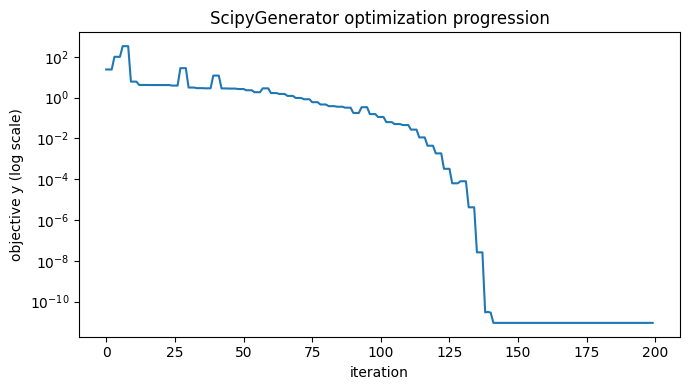

In [5]:
ax = X.data["y"].plot(figsize=(7, 4), logy=True)
ax.set_xlabel("iteration")
ax.set_ylabel("objective y (log scale)")
ax.set_title("ScipyGenerator optimization progression")
plt.tight_layout()

## Notes on performance

`ScipyGenerator` bridges scipy's in-process `minimize` API into Xopt's external evaluation loop by replaying cached points each step. This adds overhead that is small for expensive evaluations but can be noticeable for very fast toy objectives.